# Homework 5: Neural Networks with Keras

In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

2026-05-20 22:04:28.232637: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
adult = pd.read_csv('adult.csv')

adult = adult.replace('?', np.nan)
adult['income'] = (adult['income'] == '>50K').astype(int)
adult['gender'] = (adult['gender'] == 'Male').astype(int)
adult.drop(columns=['fnlwgt'], inplace=True)

# feature engineering
adult['capital_net'] = adult['capital-gain'] - adult['capital-loss']
adult['age_edu'] = adult['age'] * adult['educational-num']
adult['capital_net_log'] = np.log1p(adult['capital_net'].clip(lower=0))
adult['age_married'] = adult['age'] * (adult['marital-status'] == 'Married-civ-spouse').astype(int)

for col in ['workclass', 'occupation', 'native-country']:
    adult[col] = adult[col].fillna('Unknown')

adult.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,capital_net,age_edu,capital_net_log,age_married
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0,0,175,0.000000,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0,0,342,0.000000,38
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1,0,336,0.000000,28
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1,7688,440,8.947546,44
4,18,Unknown,Some-college,10,Never-married,Unknown,Own-child,White,0,0,0,30,United-States,0,0,180,0.000000,0


In [3]:
num_cols = [
    'age', 'educational-num', 'capital-gain', 'capital-loss',
    'hours-per-week', 'capital_net', 'capital_net_log', 'age_edu', 'age_married'
]
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

X = pd.concat([
    adult[num_cols],
    pd.get_dummies(adult[cat_cols], drop_first=True).astype(int)
], axis=1)
y = adult['income'].to_numpy()

# hold out test set before anything else
X_temp, X_test, y_temp, y_test = train_test_split(X, y, stratify=y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.15, random_state=42)

# fit scaler on train only
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

n_features = X_train.shape[1]
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (35287, 102), Val: (6228, 102), Test: (7327, 102)


In [4]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
    axes[1].plot(history.history['auc'], label='train')
    axes[1].plot(history.history['val_auc'], label='val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC'); axes[1].legend()
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X, y, label=''):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    auc = roc_auc_score(y, y_prob)
    if label:
        print(f"{label}")
    print(f"  AUC: {auc:.4f}  Acc: {accuracy_score(y, y_pred):.4f}  "
          f"F1: {f1_score(y, y_pred):.4f}  "
          f"Prec: {precision_score(y, y_pred):.4f}  Rec: {recall_score(y, y_pred):.4f}")
    return auc

## Baseline

Simple two-layer funnel (128 -> 64 -> 1)

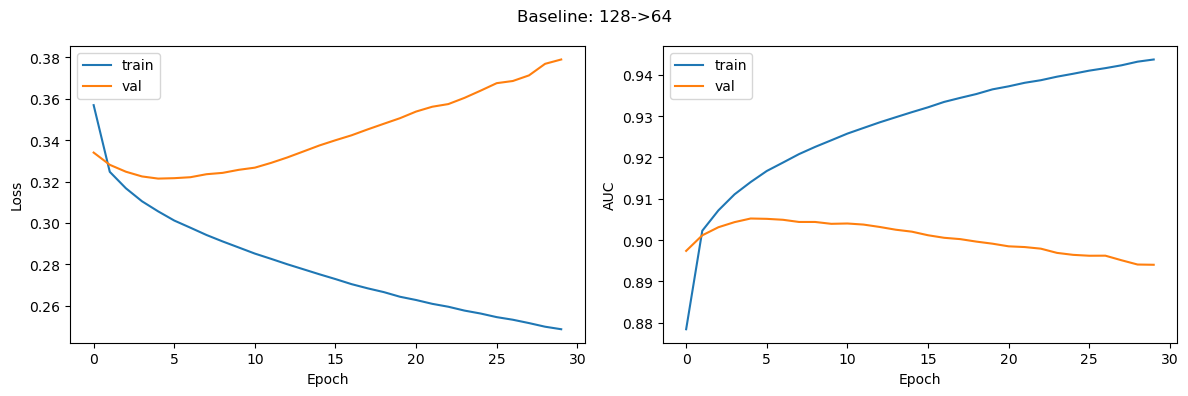

Baseline (val)
  AUC: 0.8952  Acc: 0.8433  F1: 0.6692  Prec: 0.6760  Rec: 0.6624


In [5]:
tf.random.set_seed(42)

inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
baseline_model = keras.Model(inputs=inputs, outputs=outputs)

baseline_model.compile(optimizer='adam', loss='binary_crossentropy',
                        metrics=[keras.metrics.AUC(name='auc')])

baseline_history = baseline_model.fit(
    X_train, y_train, epochs=30, batch_size=64,
    validation_data=(X_val, y_val), verbose=0
)

plot_history(baseline_history, 'Baseline: 128->64')
baseline_auc = evaluate_model(baseline_model, X_val, y_val, 'Baseline (val)')

## Experiment 1: Architecture

Changing one thing at a time: depth, width, and number of layers. Everything else stays the same as the baseline.

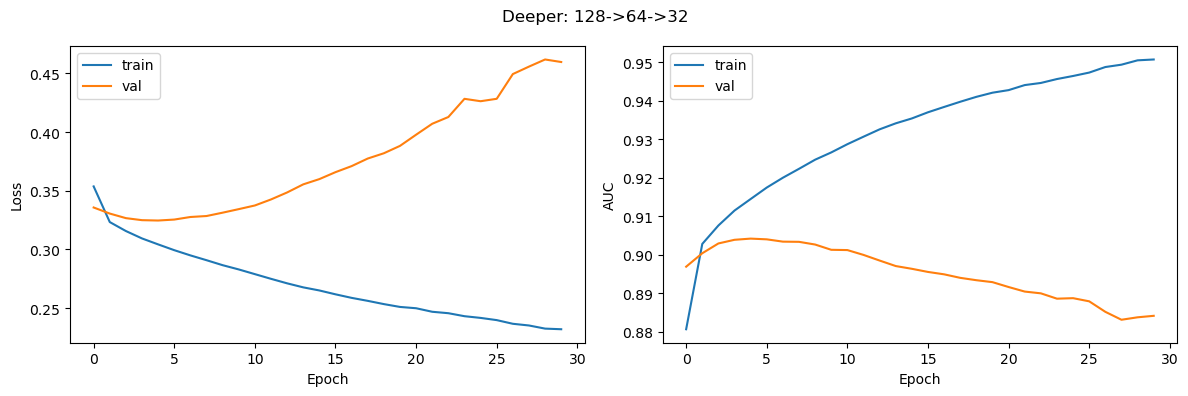

Deeper (val)
  AUC: 0.8865  Acc: 0.8362  F1: 0.6429  Prec: 0.6720  Rec: 0.6161


In [6]:
tf.random.set_seed(42)

# deeper: add a third hidden layer
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_deep = keras.Model(inputs=inputs, outputs=outputs)
model_deep.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=[keras.metrics.AUC(name='auc')])
h_deep = model_deep.fit(X_train, y_train, epochs=30, batch_size=64,
                         validation_data=(X_val, y_val), verbose=0)
plot_history(h_deep, 'Deeper: 128->64->32')
auc_deep = evaluate_model(model_deep, X_val, y_val, 'Deeper (val)')

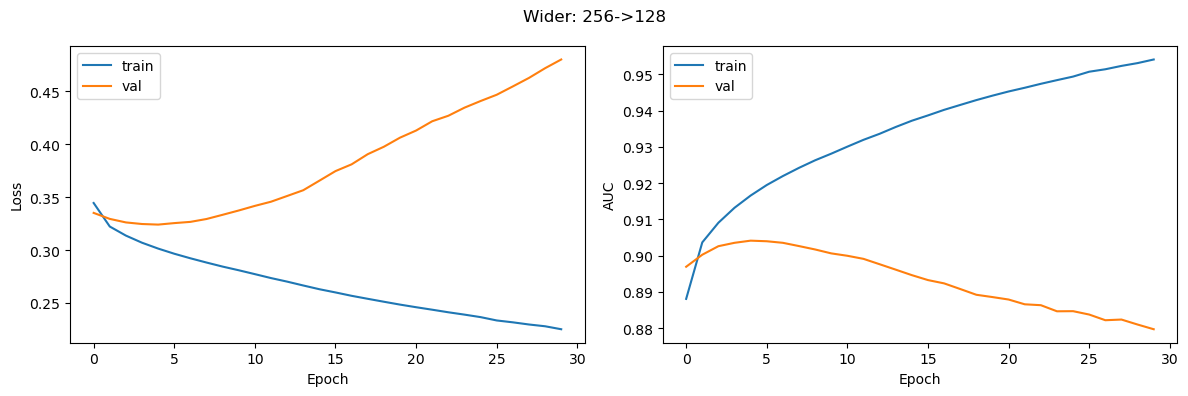

Wider (val)
  AUC: 0.8830  Acc: 0.8341  F1: 0.6461  Prec: 0.6599  Rec: 0.6329


In [7]:
tf.random.set_seed(42)

# wider: double the units in each layer
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(256, activation='relu')(inputs)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_wide = keras.Model(inputs=inputs, outputs=outputs)
model_wide.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=[keras.metrics.AUC(name='auc')])
h_wide = model_wide.fit(X_train, y_train, epochs=30, batch_size=64,
                         validation_data=(X_val, y_val), verbose=0)
plot_history(h_wide, 'Wider: 256->128')
auc_wide = evaluate_model(model_wide, X_val, y_val, 'Wider (val)')

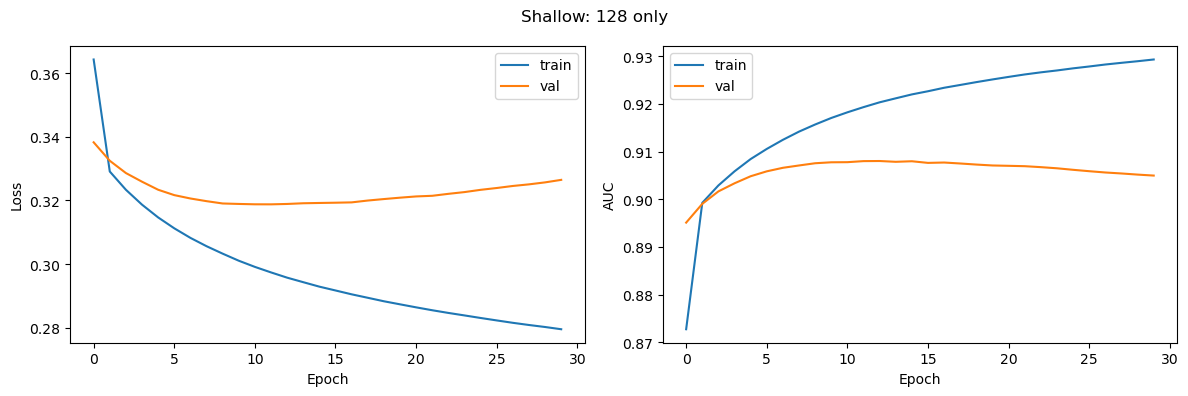

Shallow (val)
  AUC: 0.9051  Acc: 0.8489  F1: 0.6747  Prec: 0.6957  Rec: 0.6550


In [8]:
tf.random.set_seed(42)

# shallower: single hidden layer
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu')(inputs)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_shallow = keras.Model(inputs=inputs, outputs=outputs)
model_shallow.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=[keras.metrics.AUC(name='auc')])
h_shallow = model_shallow.fit(X_train, y_train, epochs=30, batch_size=64,
                               validation_data=(X_val, y_val), verbose=0)
plot_history(h_shallow, 'Shallow: 128 only')
auc_shallow = evaluate_model(model_shallow, X_val, y_val, 'Shallow (val)')

## Experiment 2: Regularization

Same baseline architecture, changing only the regularization. One factor at a time.

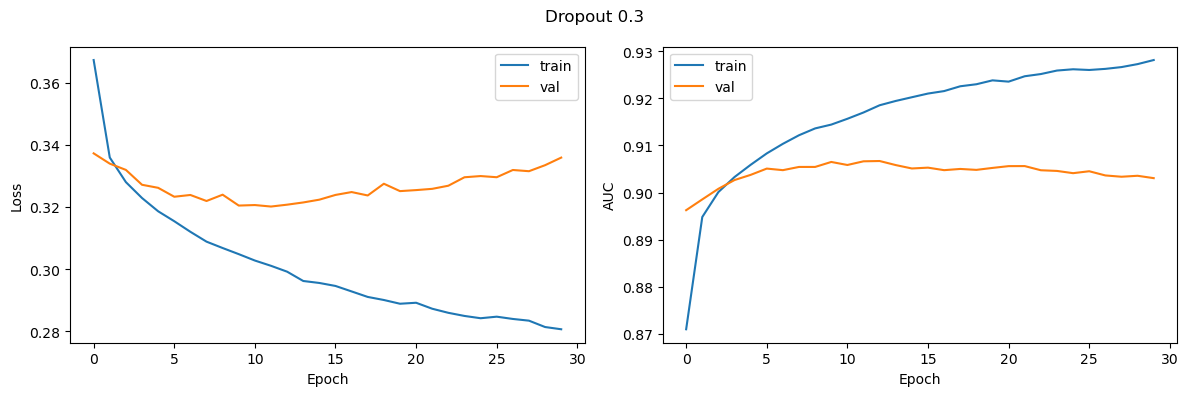

Dropout (val)
  AUC: 0.9032  Acc: 0.8539  F1: 0.6693  Prec: 0.7298  Rec: 0.6181


In [9]:
tf.random.set_seed(42)

# dropout only
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_dropout = keras.Model(inputs=inputs, outputs=outputs)
model_dropout.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=[keras.metrics.AUC(name='auc')])
h_dropout = model_dropout.fit(X_train, y_train, epochs=30, batch_size=64,
                               validation_data=(X_val, y_val), verbose=0)
plot_history(h_dropout, 'Dropout 0.3')
auc_dropout = evaluate_model(model_dropout, X_val, y_val, 'Dropout (val)')

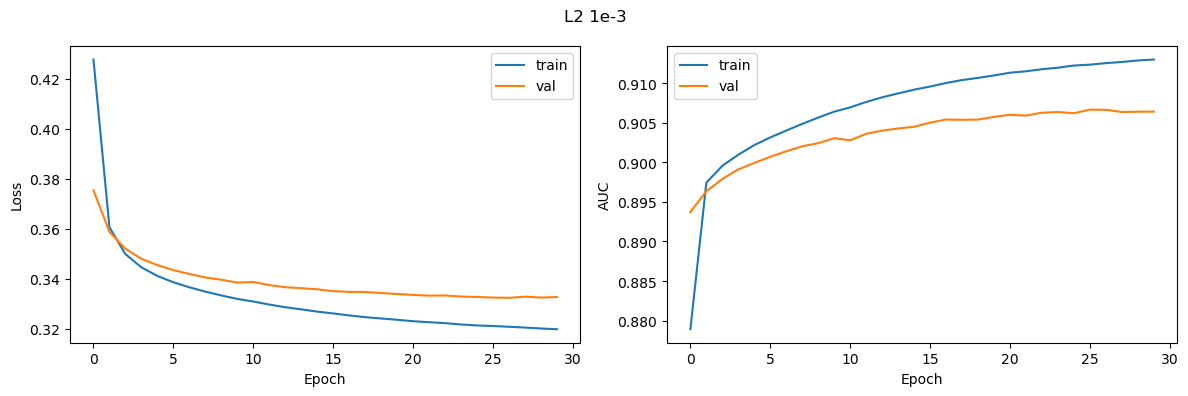

L2 (val)
  AUC: 0.9064  Acc: 0.8507  F1: 0.6686  Prec: 0.7128  Rec: 0.6295


In [10]:
tf.random.set_seed(42)

# L2 only
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(inputs)
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_l2 = keras.Model(inputs=inputs, outputs=outputs)
model_l2.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=[keras.metrics.AUC(name='auc')])
h_l2 = model_l2.fit(X_train, y_train, epochs=30, batch_size=64,
                     validation_data=(X_val, y_val), verbose=0)
plot_history(h_l2, 'L2 1e-3')
auc_l2 = evaluate_model(model_l2, X_val, y_val, 'L2 (val)')

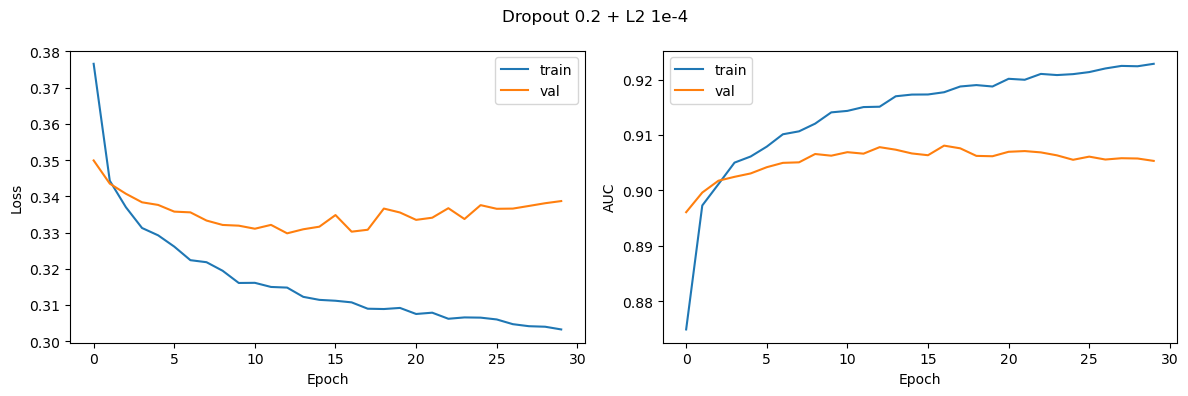

Dropout+L2 (val)
  AUC: 0.9056  Acc: 0.8499  F1: 0.6688  Prec: 0.7082  Rec: 0.6336


In [11]:
tf.random.set_seed(42)

# dropout + L2 combined at lower strengths
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_combined = keras.Model(inputs=inputs, outputs=outputs)
model_combined.compile(optimizer='adam', loss='binary_crossentropy',
                       metrics=[keras.metrics.AUC(name='auc')])
h_combined = model_combined.fit(X_train, y_train, epochs=30, batch_size=64,
                                 validation_data=(X_val, y_val), verbose=0)
plot_history(h_combined, 'Dropout 0.2 + L2 1e-4')
auc_combined = evaluate_model(model_combined, X_val, y_val, 'Dropout+L2 (val)')

## Experiment 3: Training Setup

Same architecture, changing optimizer and using early stopping.

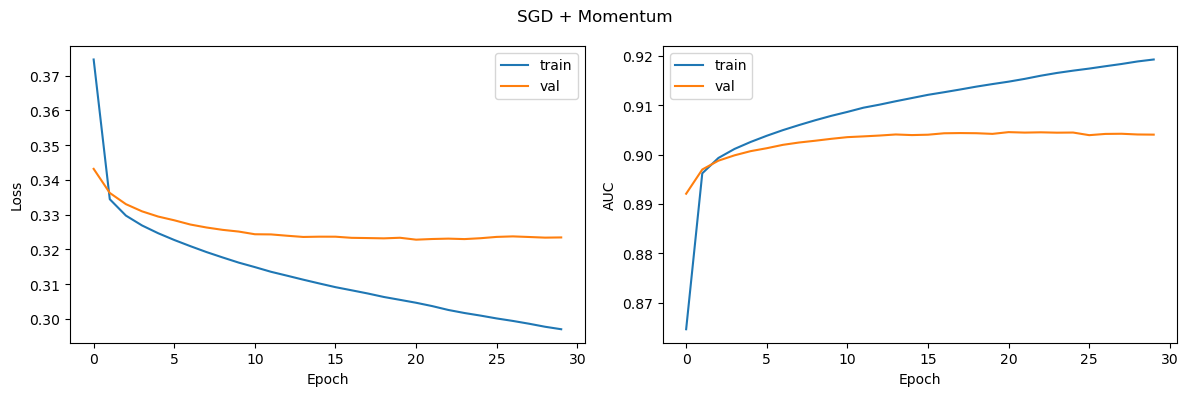

SGD (val)
  AUC: 0.9043  Acc: 0.8491  F1: 0.6469  Prec: 0.7346  Rec: 0.5779


In [12]:
tf.random.set_seed(42)

# SGD with momentum instead of Adam
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_sgd = keras.Model(inputs=inputs, outputs=outputs)
model_sgd.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
h_sgd = model_sgd.fit(X_train, y_train, epochs=30, batch_size=64,
                       validation_data=(X_val, y_val), verbose=0)
plot_history(h_sgd, 'SGD + Momentum')
auc_sgd = evaluate_model(model_sgd, X_val, y_val, 'SGD (val)')

Stopped at epoch 11


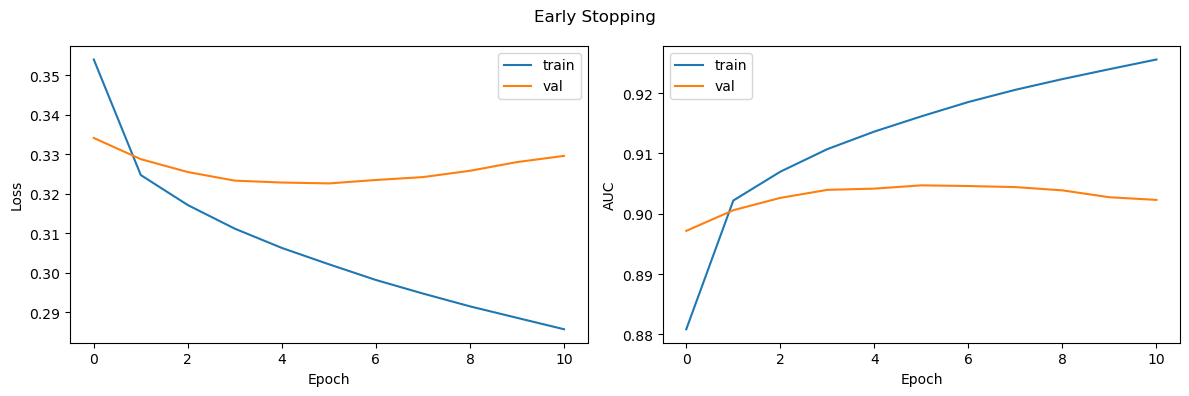

Early stopping (val)
  AUC: 0.9050  Acc: 0.8500  F1: 0.6671  Prec: 0.7112  Rec: 0.6282


In [13]:
tf.random.set_seed(42)

# early stopping with a high epoch budget - let it decide when to stop
inputs = keras.Input(shape=(n_features,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_es = keras.Model(inputs=inputs, outputs=outputs)
model_es.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=[keras.metrics.AUC(name='auc')])

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=5, mode='max', restore_best_weights=True
)
h_es = model_es.fit(X_train, y_train, epochs=100, batch_size=64,
                     validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
print(f"Stopped at epoch {len(h_es.history['loss'])}")
plot_history(h_es, 'Early Stopping')
auc_es = evaluate_model(model_es, X_val, y_val, 'Early stopping (val)')

In [14]:
results = {
    'Baseline (128->64)':      baseline_auc,
    'Deeper (128->64->32)':    auc_deep,
    'Wider (256->128)':        auc_wide,
    'Shallow (128)':           auc_shallow,
    'Dropout 0.3':             auc_dropout,
    'L2 1e-3':                 auc_l2,
    'Dropout 0.2 + L2 1e-4':  auc_combined,
    'SGD + Momentum':          auc_sgd,
    'Early Stopping':          auc_es,
}

results_df = (pd.DataFrame.from_dict(results, orient='index', columns=['Val AUC'])
                .sort_values('Val AUC', ascending=False))
print(results_df.to_string())

                        Val AUC
L2 1e-3                0.906421
Dropout 0.2 + L2 1e-4  0.905597
Shallow (128)          0.905095
Early Stopping         0.904998
SGD + Momentum         0.904332
Dropout 0.3            0.903227
Baseline (128->64)     0.895241
Deeper (128->64->32)   0.886479
Wider (256->128)       0.882989


## Optuna Tuning

Systematic search over layers, units, dropout, L2, learning rate, and batch norm. 30 trials using TPE sampler.

In [15]:
def build_model(trial, n_features):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)
    l2_strength = trial.suggest_float('l2_strength', 1e-5, 1e-2, log=True)
    use_bn = trial.suggest_categorical('use_bn', [True, False])

    inputs = keras.Input(shape=(n_features,))
    x = inputs
    for i in range(n_layers):
        units = trial.suggest_int(f'units_l{i}', 32, 256, step=32)
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_strength))(x)
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
    return model


def objective(trial):
    tf.random.set_seed(42)
    model = build_model(trial, n_features)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5, mode='max', restore_best_weights=True
    )
    model.fit(X_train, y_train, epochs=50, batch_size=64,
              validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    y_prob = model.predict(X_val, verbose=0).ravel()
    return roc_auc_score(y_val, y_prob)


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best val AUC: {study.best_value:.4f}")
print("Best params:", study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Best val AUC: 0.9106
Best params: {'n_layers': 1, 'lr': 0.00021636215073380738, 'dropout_rate': 0.3558914592389475, 'l2_strength': 5.620422295478155e-05, 'use_bn': True, 'units_l0': 224}


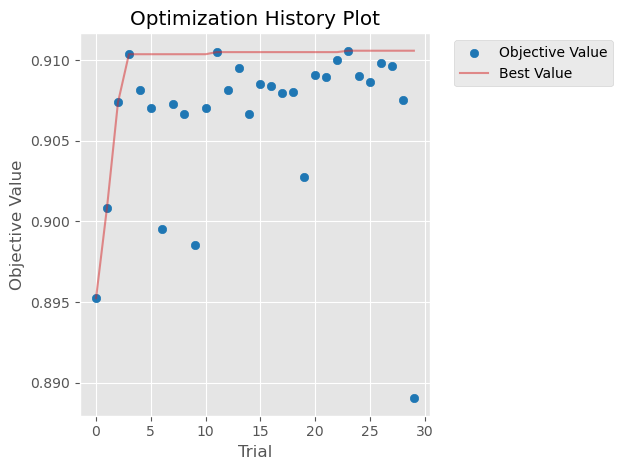

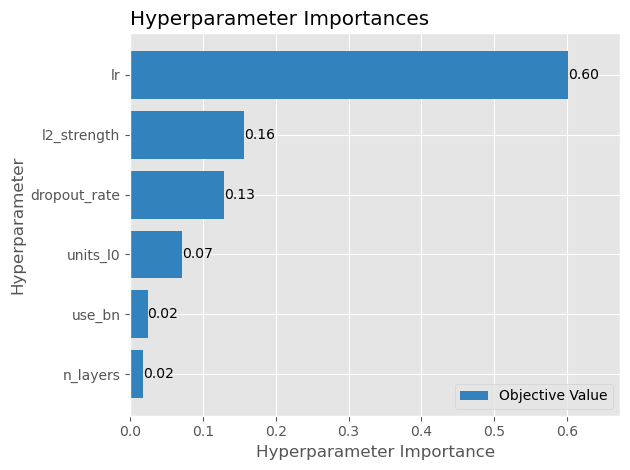

In [16]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout(); plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout(); plt.show()

## Final Model

Retrain on train+val with the best Optuna params, then evaluate on the held-out test set for the first time.

Stopped at epoch 57


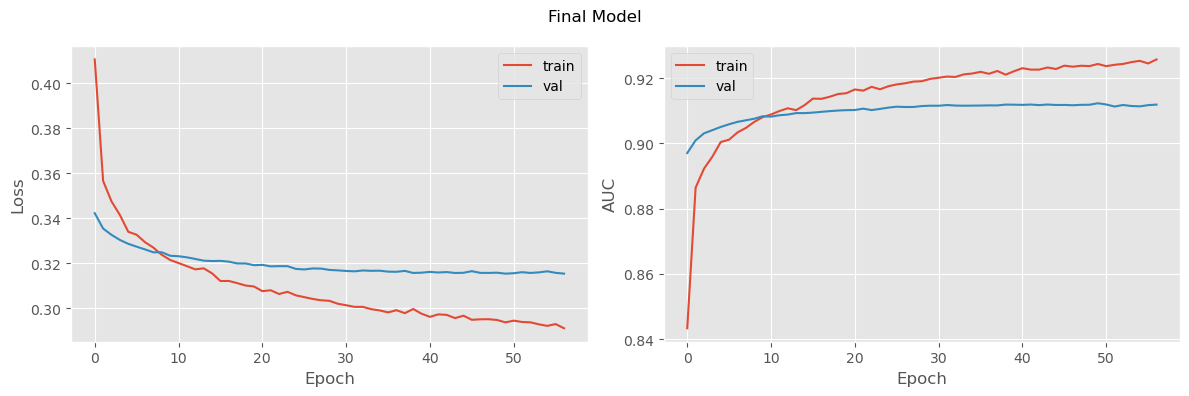

In [17]:
tf.random.set_seed(42)

X_trainval = pd.concat([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

final_model = build_model(study.best_trial, n_features)

early_stop_final = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)
final_history = final_model.fit(
    X_trainval, y_trainval, epochs=100, batch_size=64,
    validation_split=0.1, callbacks=[early_stop_final], verbose=0
)
print(f"Stopped at epoch {len(final_history.history['loss'])}")
plot_history(final_history, 'Final Model')

In [18]:
# test set evaluation - only done once
print("Baseline on test:")
baseline_test_auc = evaluate_model(baseline_model, X_test, y_test)
print("\nFinal model on test:")
final_test_auc = evaluate_model(final_model, X_test, y_test)
print(f"\nImprovement: {final_test_auc - baseline_test_auc:+.4f} AUC")

Baseline on test:
  AUC: 0.8952  Acc: 0.8462  F1: 0.6723  Prec: 0.6856  Rec: 0.6594

Final model on test:
  AUC: 0.9128  Acc: 0.8608  F1: 0.6722  Prec: 0.7697  Rec: 0.5967

Improvement: +0.0176 AUC


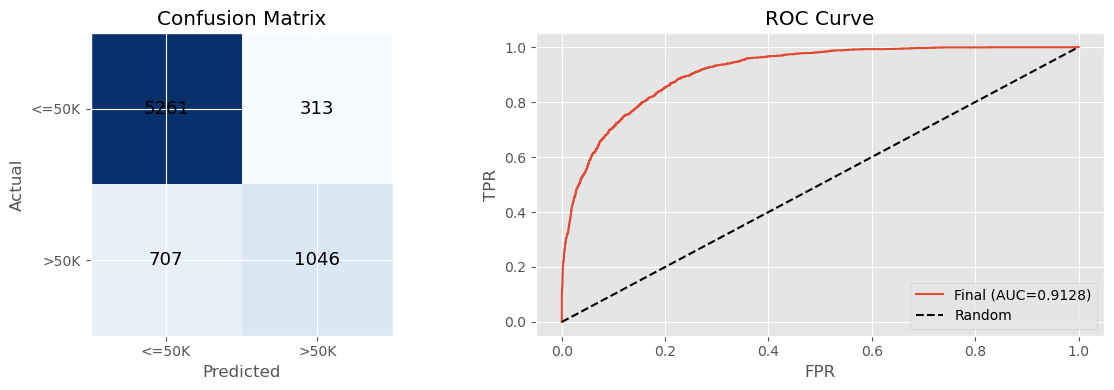

In [19]:
from sklearn.metrics import roc_curve

y_prob_test = final_model.predict(X_test, verbose=0).ravel()
y_pred_test = (y_prob_test > 0.5).astype(int)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['<=50K', '>50K']); axes[0].set_yticklabels(['<=50K', '>50K'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=13)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, label=f'Final (AUC={final_test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout(); plt.show()

## Personal Workflow

In the future, I would start by clearly understanding the goal of the model before changing any settings. I would first look at the data, check the target variable, clean missing values, and make sure the features are in a format the neural network can actually use. I would also scale the numeric variables because neural networks are sensitive to feature size, and skipping that step can make the model train poorly.
After preparing the data, I would start with a simple baseline model first. I think this is important because it gives me something to compare the neural network to. Then, I would build a basic neural network with only a few layers and see how it performs before making it more complex. I would prioritize decisions like the number of hidden layers, number of neurons, activation functions, optimizer, batch size, and epochs, but I would change these one at a time so I can tell what actually helped.
When evaluating the model, I would look at both training and validation performance. One big thing I would watch for is overfitting. If the training accuracy keeps improving but the validation accuracy stops improving or gets worse, then the model is probably memorizing the training data instead of learning patterns. In that case, I would try things like reducing the model size, adding dropout, using early stopping, or training for fewer epochs.
Overall, my workflow would be: understand the problem, clean and scale the data, create a baseline, build a simple neural network, tune it step by step, and evaluate it using validation results instead of only training results. The biggest best practice I took away is not to make the model complicated too quickly. A neural network should be built carefully and compared against simpler models so I know the extra complexity is actually worth it.